Loading Data & Generating Artifacts...
Loading Run: HUV_Benchmark_Optimized (ID: 1)


### Full Logistic Regression Analysis

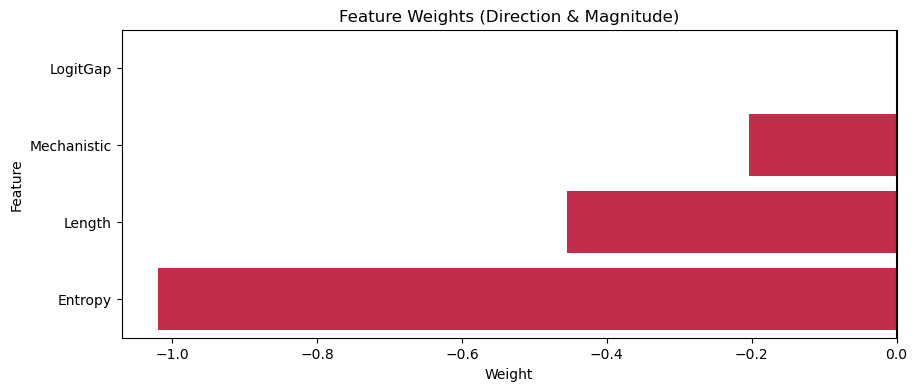

              precision    recall  f1-score   support

           0       0.41      0.63      0.50       364
           1       0.90      0.79      0.84      1572

    accuracy                           0.76      1936
   macro avg       0.65      0.71      0.67      1936
weighted avg       0.81      0.76      0.78      1936



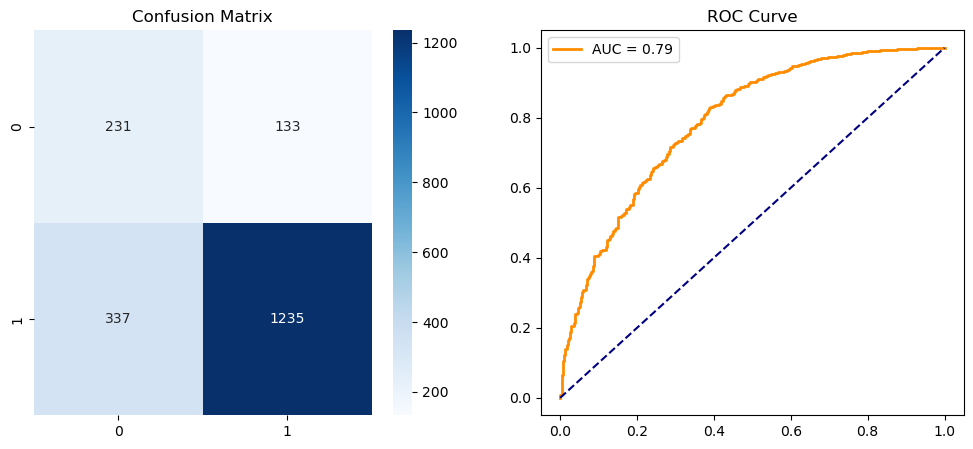

### Full Logistic Regression Analysis

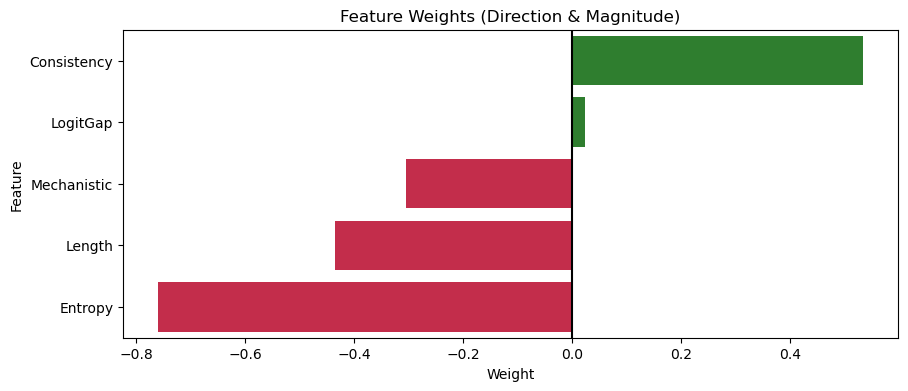

              precision    recall  f1-score   support

           0       0.41      0.65      0.50       364
           1       0.91      0.78      0.84      1572

    accuracy                           0.76      1936
   macro avg       0.66      0.72      0.67      1936
weighted avg       0.81      0.76      0.78      1936



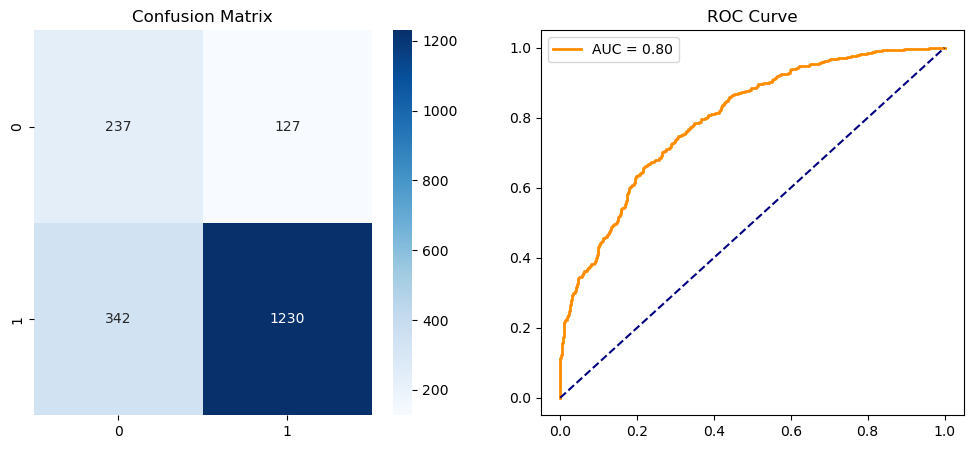

Metric,Shift (SD),Mean,SD,Vis
Entropy,+1.91 SD,0.131,0.047,
LogitGap,-0.10 SD,0.032,0.034,
Mechanistic,+1.16 SD,0.976,0.005,
Length,+0.02 SD,265.910,94.047,
Metric,Shift (SD),Mean,SD,Vis
Entropy,+0.03 SD,0.058,0.018,
LogitGap,+0.03 SD,0.043,0.041,
Mechanistic,+0.14 SD,0.967,0.005,
Length,+0.54 SD,307.863,68.973,
Metric,Shift (SD),Mean,SD,Vis


Generating t-SNE...


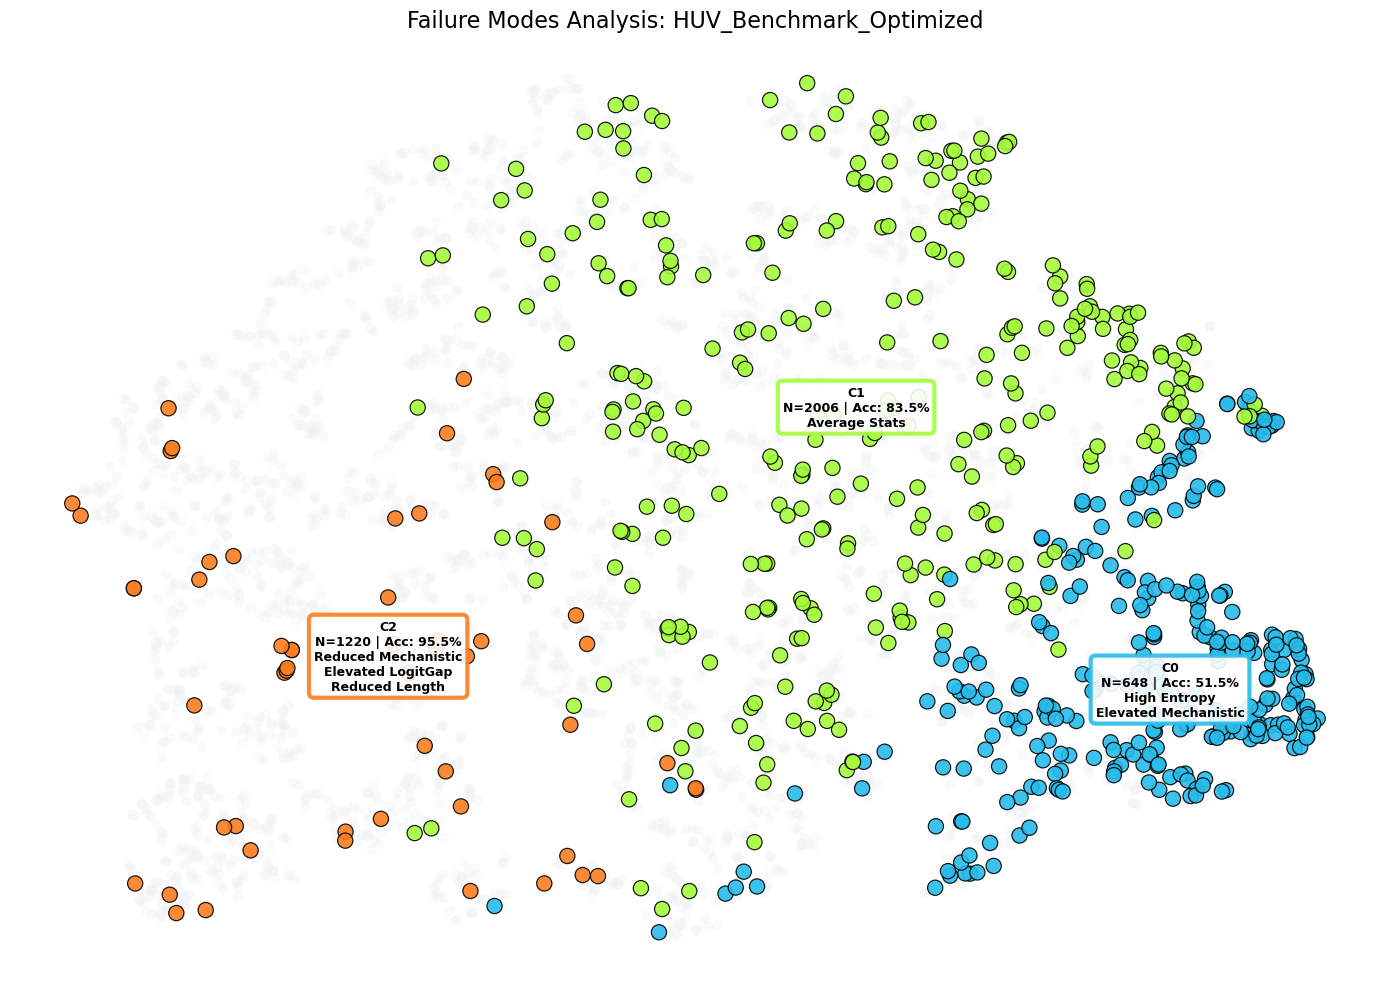

In [1]:
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib

importlib.reload(utils)
print("Loading Data & Generating Artifacts...")
df, metrics, exp_info = utils.load_data_universal("db/results.sqlite")

metrics_to_use = ['Entropy', 'LogitGap', 'Mechanistic','Length'] # 'Consistency', 

logistic_predictor = utils.run_detailed_logistic_regression(df, features=metrics_to_use)

logistic_predictor_with_consistency = utils.run_detailed_logistic_regression(df, features=metrics_to_use + ["Consistency"])

cluster_predictor = utils.run_failure_modes_dashboard(df, exp_info, features=metrics_to_use)

In [2]:
# 1. Capture Logistic Fusion Probabilities (Index 0)
df['Logistic_Fusion'], _ = logistic_predictor(df)

# 1. Capture Logistic Fusion Probabilities (Index 0)
df['Logistic_Fusion_Consistency'], _ = logistic_predictor_with_consistency(df)

# 2. Capture Cluster Labels (Index 1)
_, df['Cluster_Label'] = cluster_predictor(df)

# 3. (Optional) Capture Cluster Confidence if needed
df['Cluster_Conf'], _ = cluster_predictor(df)

# Verify
print(df[['Logistic_Fusion', 'Cluster_Label']].head())

   Logistic_Fusion                                      Cluster_Label
0         0.810163  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
1         0.894917  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
2         0.899839  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
3         0.898509  C2\nN=1220 | Acc: 95.5%\nReduced Mechanistic\n...
4         0.515271             C1\nN=2006 | Acc: 83.5%\nAverage Stats


In [3]:
utils.run_comparison_dashboard(df, logistic_predictor, cluster_predictor, metrics_to_use)

,AUROC (↑),ECE (↓),MSE (↓),Status
Model,,,,
Logistic Fusion,0.7981,0.2318,0.1745,
Cluster Baseline,0.7379,0.0000,0.1265,🏆 Winner
Entropy,0.7692,0.0368,0.1277,
LogitGap,0.3659,0.1576,0.1803,
Mechanistic,0.2445,0.1832,0.1791,
Length,0.6327,0.3419,0.2640,


Model,Mn,Rg
Logistic Fusion,0.58,0.74
Cluster Baseline,0.84,0.00
Entropy,0.87,0.26
LogitGap,0.95,0.44
Mechanistic,0.79,0.33
Length,0.41,0.77
Model,Mn,Rg
Logistic Fusion,0.79,0.59
Cluster Baseline,0.95,0.00
Entropy,0.90,0.40


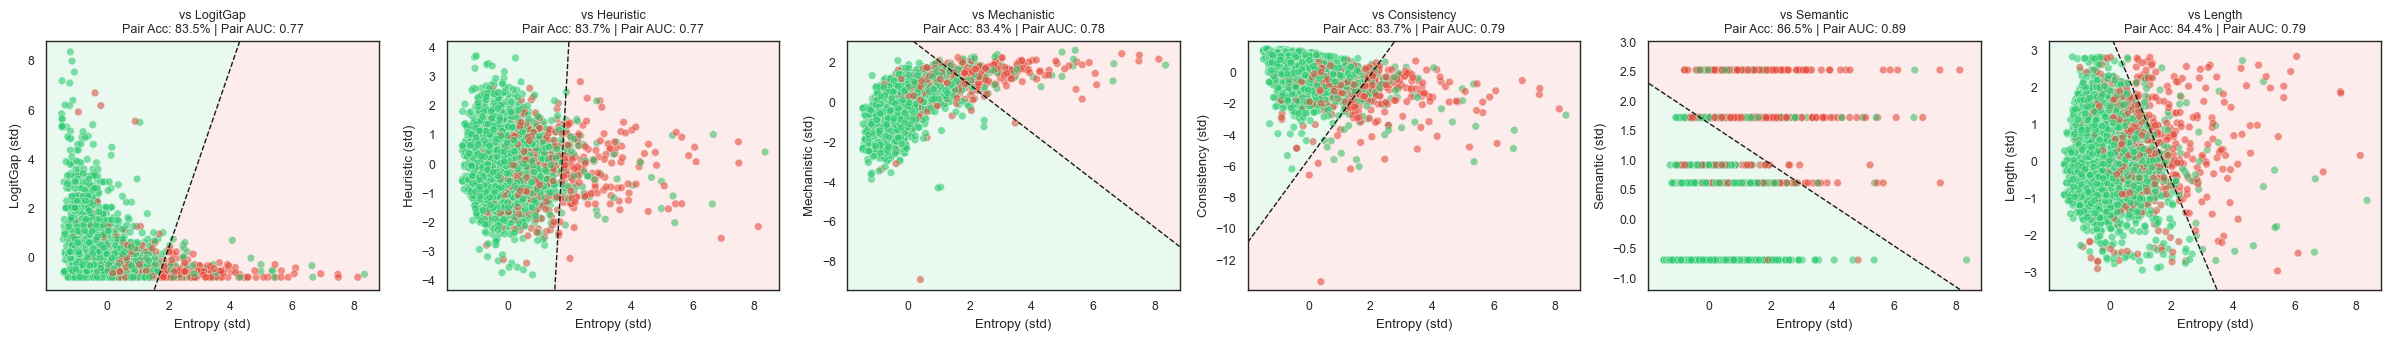

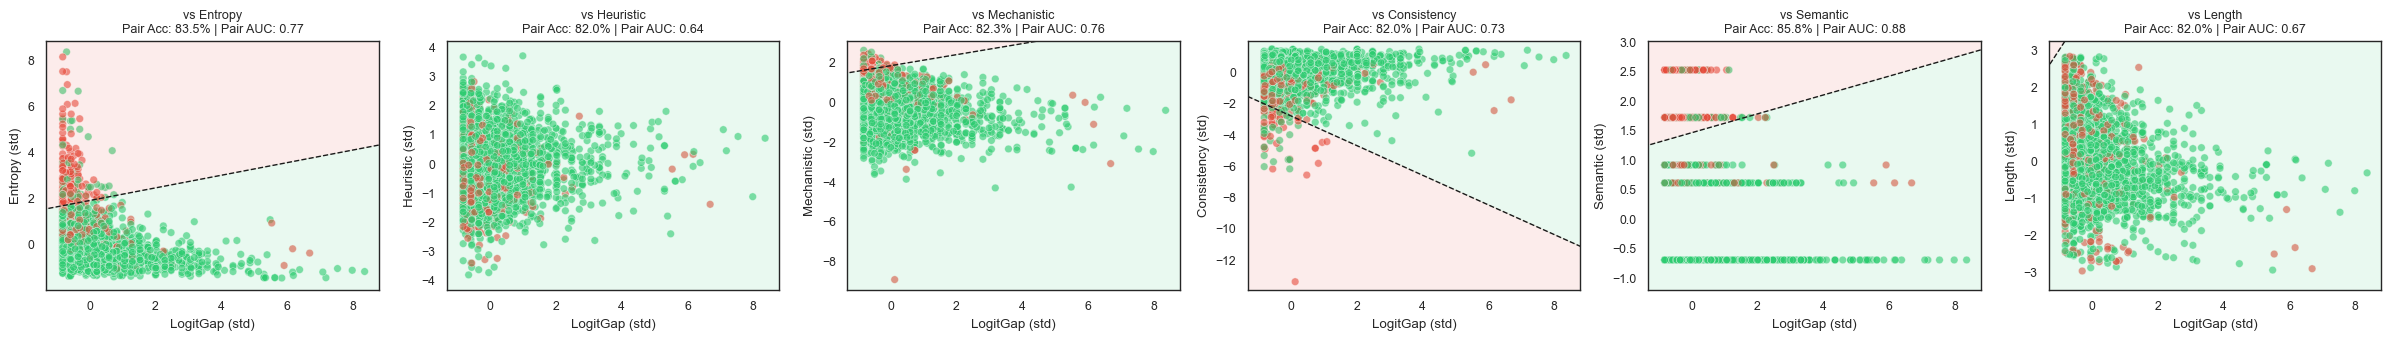

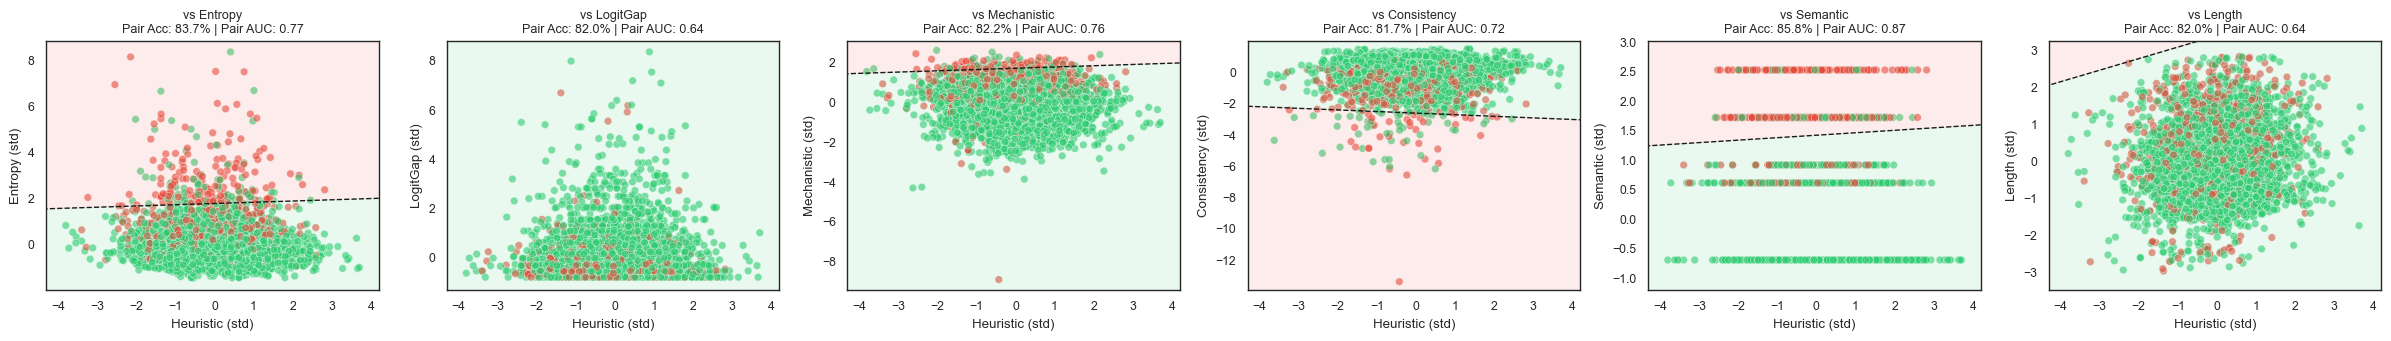

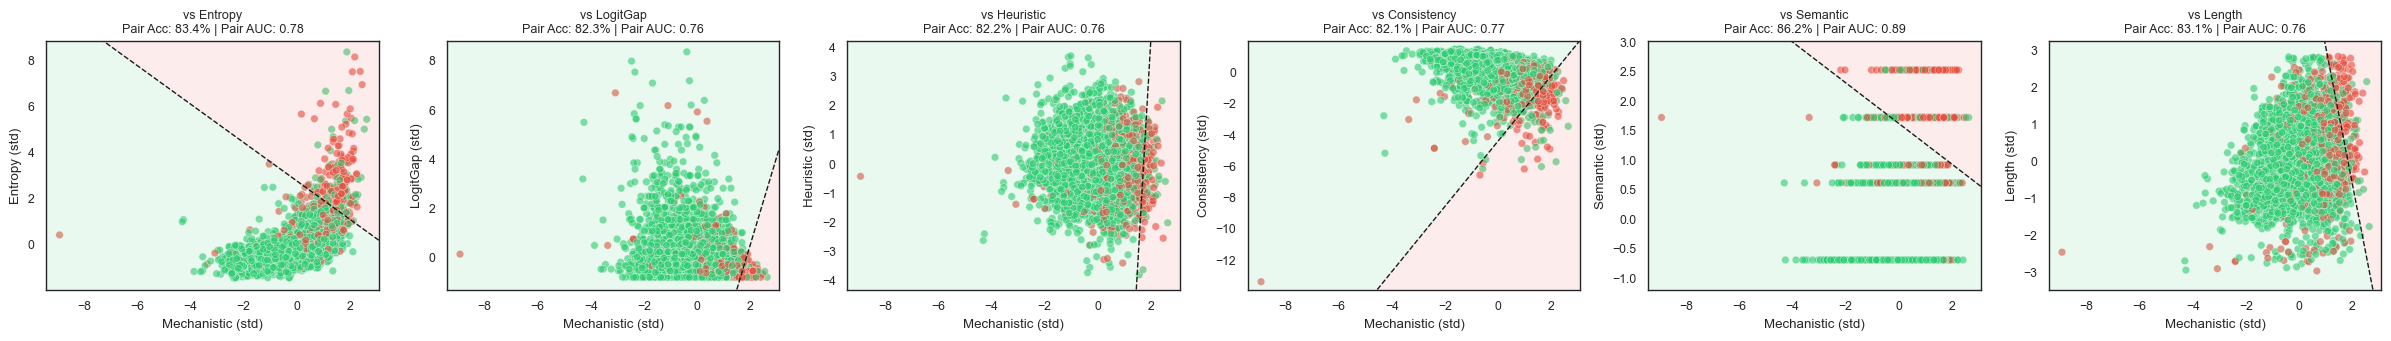

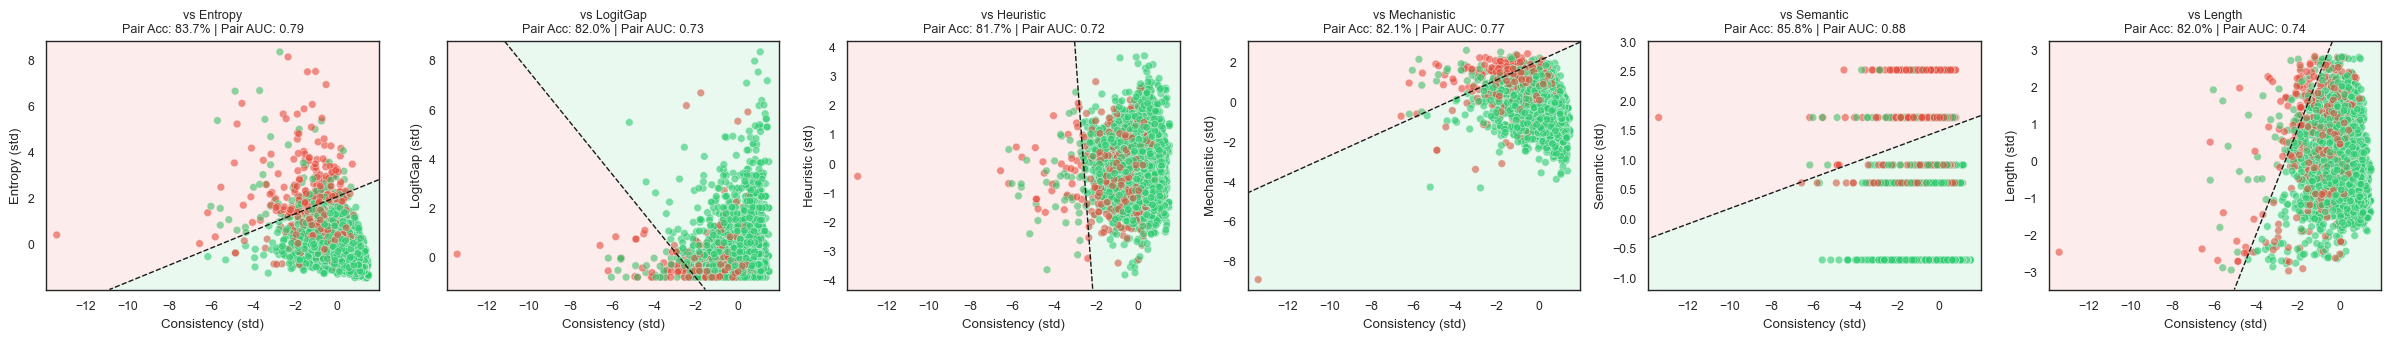

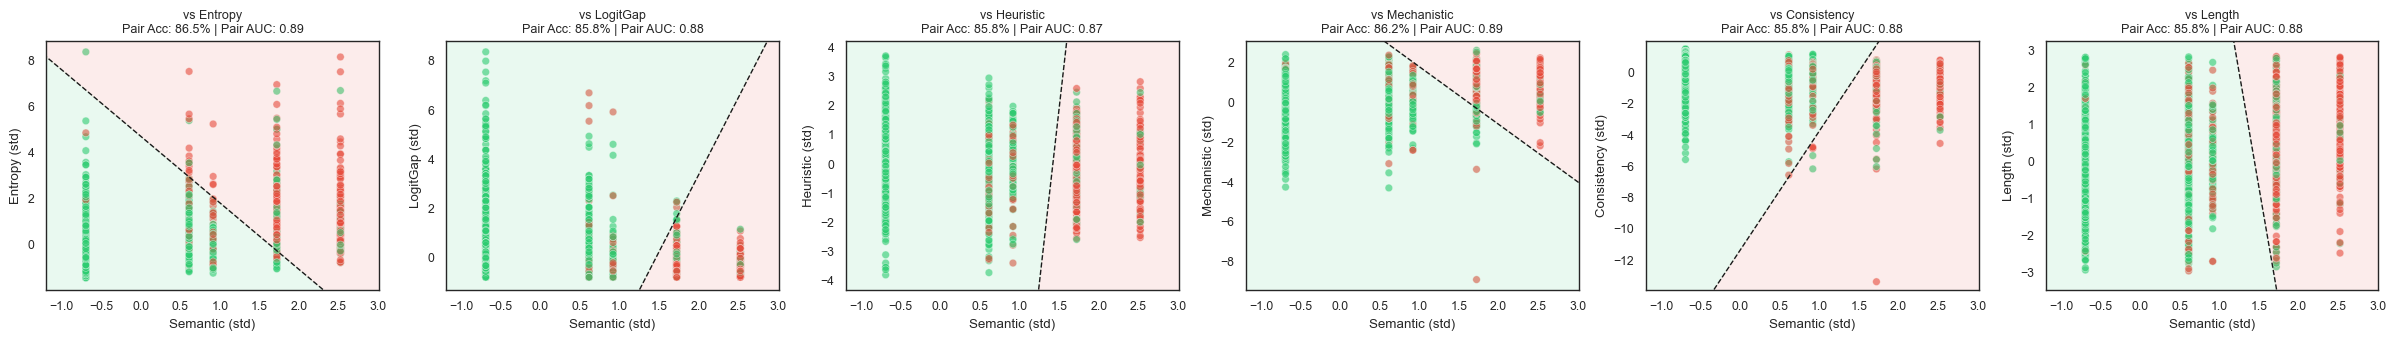

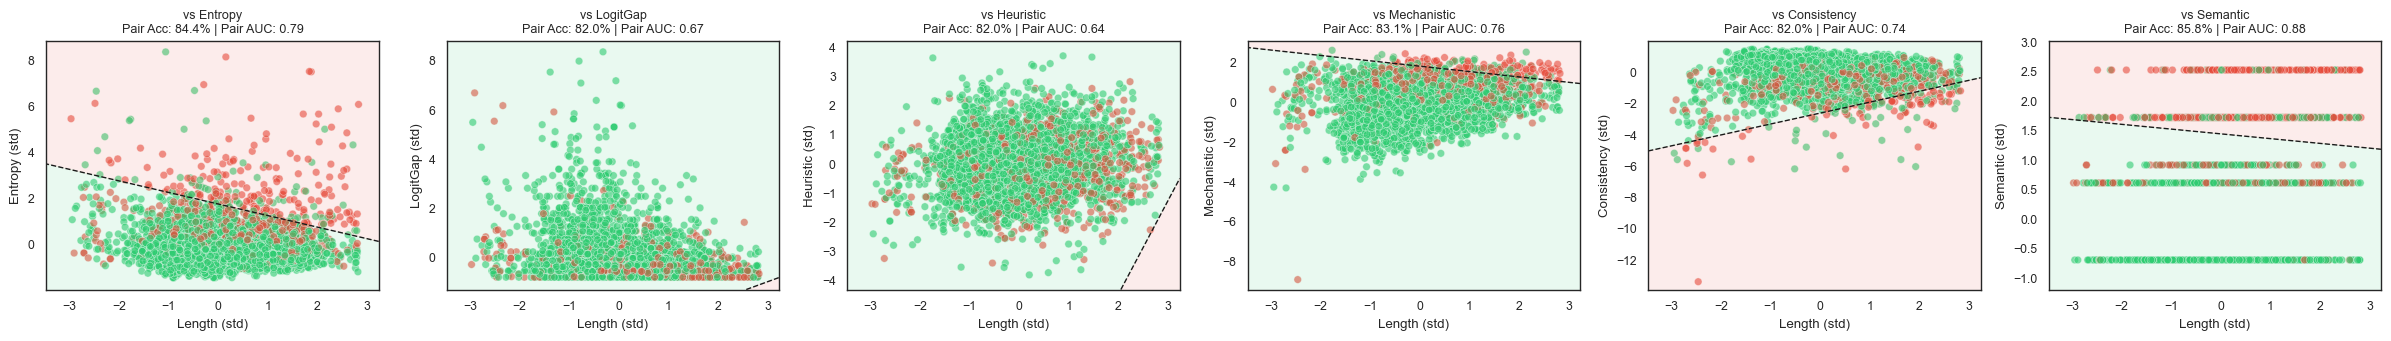

{'Entropy': <analysis_utils.PredictorArtifact at 0x340b19490>,
 'LogitGap': <analysis_utils.PredictorArtifact at 0x35b69f910>,
 'Heuristic': <analysis_utils.PredictorArtifact at 0x3429e0610>,
 'Mechanistic': <analysis_utils.PredictorArtifact at 0x346791010>,
 'Consistency': <analysis_utils.PredictorArtifact at 0x35ba08490>,
 'Semantic': <analysis_utils.PredictorArtifact at 0x35bbe8c90>,
 'Length': <analysis_utils.PredictorArtifact at 0x34374be90>}

In [4]:
utils.run_full_analysis(df,metrics)

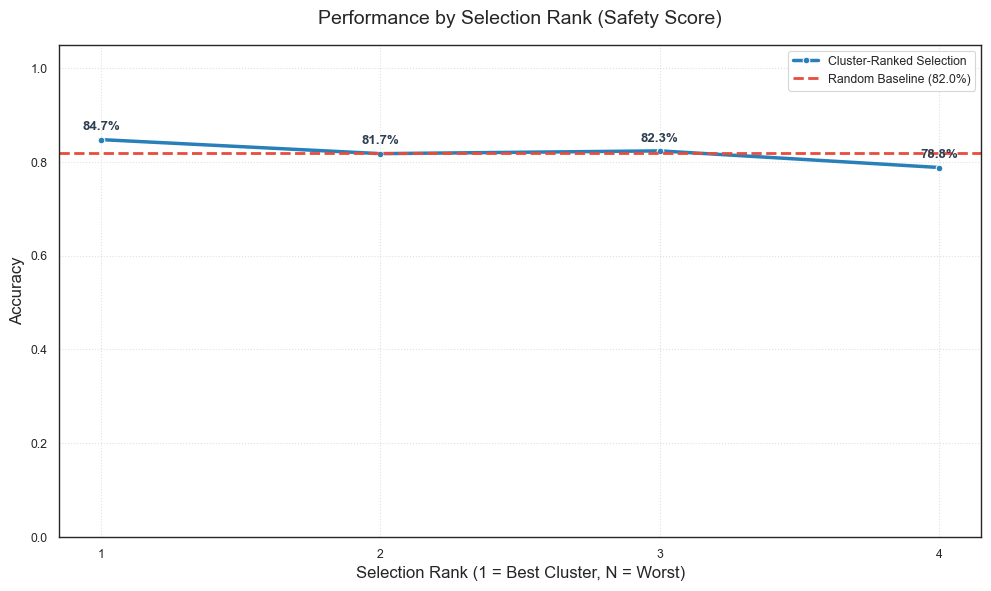


🔍 TOP 3 HIGH-CONTRAST EXAMPLES (Showing Rank Ordering)

📌 QUESTION 1:
Travis and his brother joined a trick-or-treat event. They collected 68 pieces of candy altogether. Each of them ate 4 pieces of candy after the event. How many pieces of candy were left?

👇 Ranked Candidates:
   Rank #1 ✅ [Safe: 97.6%] ->  Travis and his brother initially had 68 pieces of candy together. After eating 4 pieces each, they ...
   Rank #2 ✅ [Safe: 91.2%] ->  To determine how many pieces of candy Travis and his brother have left, we need to follow these ste...
   Rank #3 ✅ [Safe: 40.6%] ->  Travis and his brother initially had 68 pieces of candy together.  After eating 4 pieces each, they...
   Rank #4 ❌ [Safe: 25.5%] ->  Travis and his brother together had 68 - (2 * 4) = 50 pieces of candy. The answer is 50....
--------------------------------------------------------------------------------

📌 QUESTION 2:
Leticia, Nina, and Rosalie have a total of 25 people on their dance team. If 8 people quit, but 13

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

def analyze_intra_question_rank_performance(df):
    """
    Analyzes performance by rank:
    1. Clusters answers to generate a 'Safety_Score'.
    2. Ranks answers per question (1st best, 2nd best, etc.) by this score.
    3. Plots the specific accuracy for every rank position.
    """
    
    # --- 1. ROBUST PRE-PROCESSING ---
    col_map = {
        'uq_avg_entropy': 'Entropy',
        'uq_heuristic_score': 'LogitGap', 
        'uq_mech_score': 'Mechanistic',
        'is_correct': 'Correct',
        'question_text': 'Question',
        'predicted_answer': 'Answer_Text'
    }
    
    work_df = df.copy()
    
    # Avoid duplicate column errors
    for source, target in col_map.items():
        if source in work_df.columns and target in work_df.columns:
            work_df.drop(columns=[target], inplace=True)
            
    work_df.rename(columns={k: v for k, v in col_map.items() if k in work_df.columns}, inplace=True)
    work_df = work_df.loc[:, ~work_df.columns.duplicated()]

    # Feature engineering
    features = ['Entropy', 'LogitGap', 'Mechanistic']
    for f in features:
        if f not in work_df.columns: work_df[f] = 0.0

    # --- 2. CLUSTERING & SCORING ---
    X = work_df[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Dynamic K
    n_clusters = min(10, len(work_df)//5) if len(work_df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    work_df['Cluster_ID'] = kmeans.fit_predict(X_scaled)
    
    # Safety Score = Cluster's average accuracy
    cluster_accs = work_df.groupby('Cluster_ID')['Correct'].mean()
    work_df['Safety_Score'] = work_df['Cluster_ID'].map(cluster_accs)

    # --- 3. COMPUTE RANK PERFORMANCE ---
    grouped = work_df.groupby('Question')
    multi_ans = [g for _, g in grouped if len(g) > 1]
    
    if not multi_ans:
        print("⚠️ No questions with multiple answers found to rank.")
        return

    rank_data = []

    for _, group in grouped:
        # Sort answers by Safety Score (High is better)
        # We use a stable sort so that ties retain original order (or add secondary sort keys if available)
        ranked_group = group.sort_values('Safety_Score', ascending=False).reset_index(drop=True)
        
        for rank_idx, row in ranked_group.iterrows():
            rank_data.append({
                'Rank': rank_idx + 1,  # 1-based index (1st pick, 2nd pick...)
                'Correct': row['Correct'],
                'Safety_Score': row['Safety_Score'],
                'Question': row['Question']
            })
            
    rank_df = pd.DataFrame(rank_data)

    # --- 4. VISUALIZATION OF RANKS ---
    
    # Calculate accuracy per rank
    rank_performance = rank_df.groupby('Rank')['Correct'].agg(['mean', 'count']).reset_index()
    rank_performance.rename(columns={'mean': 'Accuracy', 'count': 'Sample_Size'}, inplace=True)
    
    # Filter out ranks with very few samples (noise) if data is ragged
    min_samples = max(5, len(grouped) * 0.1) 
    rank_performance = rank_performance[rank_performance['Sample_Size'] >= min_samples]

    # Global Random Baseline (Average accuracy across all rows)
    global_baseline = work_df['Correct'].mean()
    
    # Calculate Gain (1st Pick vs Baseline)
    top_pick_acc = rank_performance.loc[rank_performance['Rank'] == 1, 'Accuracy'].values[0]
    gain = top_pick_acc - global_baseline

    # HTML Summary
    html = f"""
    <div style='background:#f4f6f7; padding:15px; border-radius:8px; border-left: 5px solid #2980b9; font-family:sans-serif;'>
        <h3 style='margin:0; color:#2c3e50;'>📈 Rank Strategy Analysis</h3>
        <p style='margin:5px 0 0 0;'>
            <strong>Top Pick Accuracy:</strong> {top_pick_acc:.1%} <span style='color:#27ae60;'>(+{gain:.1%} vs Base)</span><br>
            <strong>Random Baseline:</strong> {global_baseline:.1%}<br>
            <strong>Decay:</strong> Accuracy drops as we move to lower-ranked safety clusters.
        </p>
    </div>
    """
    display(HTML(html))

    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot the Rank Curve
    sns.lineplot(
        data=rank_performance, 
        x='Rank', 
        y='Accuracy', 
        marker='o', 
        linewidth=2.5,
        color='#2980b9', 
        label='Cluster-Ranked Selection'
    )
    
    # Plot Baseline
    plt.axhline(y=global_baseline, color='#e74c3c', linestyle='--', linewidth=2, label=f'Random Baseline ({global_baseline:.1%})')
    
    # Formatting
    plt.title("Performance by Selection Rank (Safety Score)", fontsize=14, pad=15)
    plt.xlabel("Selection Rank (1 = Best Cluster, N = Worst)", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rank_performance['Rank'].unique())
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    
    # Annotate points
    for i in range(len(rank_performance)):
        row = rank_performance.iloc[i]
        plt.text(
            row['Rank'], 
            row['Accuracy'] + 0.02, 
            f"{row['Accuracy']:.1%}", 
            ha='center', 
            color='#2c3e50',
            fontweight='bold'
        )
        
    plt.tight_layout()
    plt.show()

    # --- 5. PRINT EXAMPLES (Optional: Top 3 High Contrast) ---
    print("\n" + "="*80)
    print("🔍 TOP 3 HIGH-CONTRAST EXAMPLES (Showing Rank Ordering)")
    print("="*80 + "\n")
    
    # Find questions with high variance in safety scores
    contrast_list = []
    for q_text, g in grouped:
        if len(g) > 1:
            diff = g['Safety_Score'].max() - g['Safety_Score'].min()
            contrast_list.append((diff, q_text, g))
            
    contrast_list.sort(key=lambda x: x[0], reverse=True)
    
    for i, (_, q_text, g) in enumerate(contrast_list[:3]):
        # Sort current group by safety score
        g_sorted = g.sort_values('Safety_Score', ascending=False)
        
        print(f"📌 QUESTION {i+1}:")
        print(f"{q_text[:300]}..." if len(q_text) > 300 else q_text)
        print("\n👇 Ranked Candidates:")
        
        rank_counter = 1
        for _, row in g_sorted.iterrows():
            marker = "✅" if row['Correct'] == 1 else "❌"
            # Get raw answer text safely
            ans_text = str(row.get('full_trace_text', row.get('Answer_Text', 'N/A')))[:100].replace('\n', ' ')
            
            print(f"   Rank #{rank_counter} {marker} [Safe: {row['Safety_Score']:.1%}] -> {ans_text}...")
            rank_counter += 1
        print("-" * 80 + "\n")

# Usage
analyze_intra_question_rank_performance(df)

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import auc
from scipy.stats import pointbiserialr

def plot_auarc_analysis(df, metrics_to_use):
    """
    Plots AUARC with empirical directionality correction.
    
    It calculates the correlation between the metric and correctness.
    - If Correlation > 0: High Metric = High Confidence (Keep as is)
    - If Correlation < 0: Low Metric = High Confidence (Flip sign)
    """
    
    # 1. Setup Predictors
    predictors = metrics_to_use.copy()
    # if 'Logistic Fusion' in df.columns: predictors.insert(0, 'Logistic Fusion')
    # if 'Cluster Baseline' in df.columns: predictors.insert(1, 'Cluster Baseline')
    
    plt.figure(figsize=(10, 6))
    
    # 2. Plot Baseline
    base_acc = df['Correct'].mean()
    plt.axhline(base_acc, color='black', linestyle='--', alpha=0.5, label=f'Baseline Acc ({base_acc:.1%})')
    
    for model in predictors:
        if model not in df.columns:
            print(f"Warning: {model} not found in DataFrame.")
            continue
        
        # Fill NaNs so correlation doesn't break
        raw_vals = df[model].fillna(df[model].mean())
        
        # 3. EMPIRICAL DIRECTIONALITY CHECK
        # Calculate correlation between metric and binary correctness
        # r > 0 implies higher metric values -> higher correctness
        # r < 0 implies higher metric values -> lower correctness (needs inversion)
        r, _ = pointbiserialr(raw_vals, df['Correct'])
        
        direction_label = ""
        if r < 0:
            # Negative correlation: Lower values are better (e.g., Entropy)
            confidence_scores = -1 * raw_vals
            direction_label = " (Inv)"
        else:
            # Positive correlation: Higher values are better (e.g., LogitGap)
            confidence_scores = raw_vals
            
        # 4. Sort Data by Confidence (High -> Low)
        sorted_df = pd.DataFrame({'y': df['Correct'], 'conf': confidence_scores})
        sorted_df = sorted_df.sort_values('conf', ascending=False)
        
        y_sorted = sorted_df['y'].values
        n = len(y_sorted)
        
        # 5. Calculate Curve
        rejection_rates = np.linspace(0, 0.95, 100) # Increased resolution
        accuracies = []
        
        for rr in rejection_rates:
            n_keep = int(n * (1 - rr))
            if n_keep < 10: break # Avoid instability with too few samples
            acc = np.mean(y_sorted[:n_keep])
            accuracies.append(acc)
            
        # 6. Plot
        valid_rr = rejection_rates[:len(accuracies)]
        score = auc(valid_rr, accuracies)
        
        # Formatting for special baselines
        is_baseline = 'Logistic' in model or 'Cluster' in model
        lw = 3 if is_baseline else 1.5
        alpha = 1.0 if is_baseline else 0.8
        
        plt.plot(valid_rr, accuracies, lw=lw, alpha=alpha, 
                 label=f'{model}{direction_label} (AUARC: {score:.3f})')

    plt.xlabel('Rejection Rate (Fraction Refused)')
    plt.ylabel('Accuracy of Remaining Answers')
    plt.title('Accuracy-Rejection Curve (Empirical Direction)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

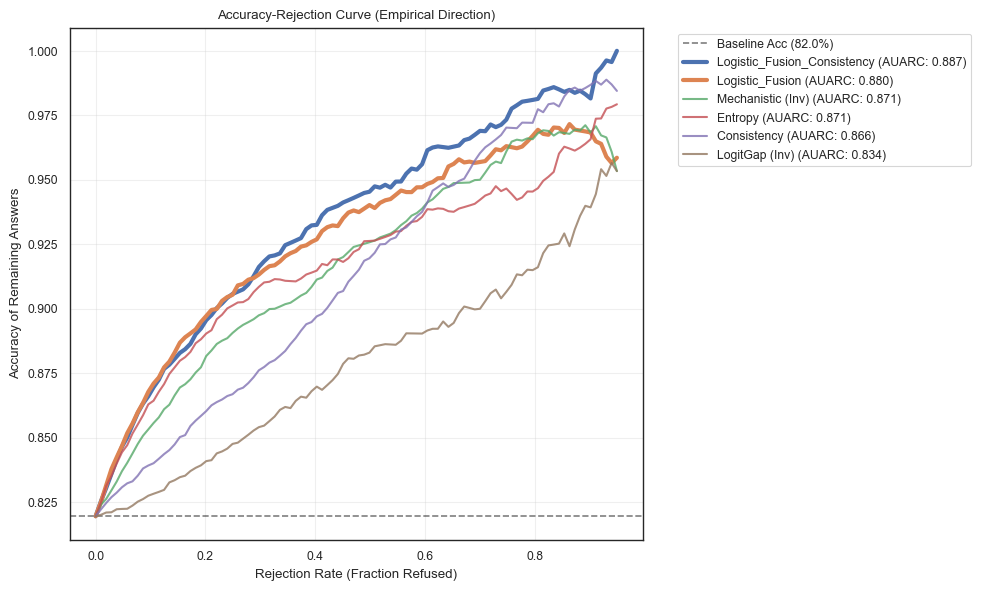

In [7]:
# 1. Convert Text Labels to Numerical Scores (Cluster Accuracy)
# This creates a baseline: "My confidence is the average accuracy of this cluster"
cluster_accs = df.groupby('Cluster_Label')['Correct'].mean()
df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

# 2. Update the list to use the Numerical column
metrics_to_plot = ["Logistic_Fusion_Consistency", "Logistic_Fusion", "Mechanistic", "Entropy", "Consistency", "LogitGap"] 

# 3. Plot
plot_auarc_analysis(df, metrics_to_plot)

In [8]:
df.keys()

Index(['result_id', 'question_id_external', 'question_text', 'gold_answer',
       'predicted_answer', 'full_trace_text', 'is_correct', 'Entropy',
       'LogitGap', 'Heuristic', 'Mechanistic', 'Consistency',
       'similarity_vector', 'uq_tokens', 'uq_mech_trace', 'uq_entropy_trace',
       'uq_logit_gap_trace', 'Correct', 'Semantic', 'Length', 'Entropy_Z',
       'LogitGap_Z', 'Heuristic_Z', 'Mechanistic_Z', 'Consistency_Z',
       'Semantic_Z', 'Length_Z', 'Cluster', 'x', 'y', 'Logistic_Fusion',
       'Logistic_Fusion_Consistency', 'Cluster_Label', 'Cluster_Conf',
       'Logistic Fusion', 'Cluster Baseline'],
      dtype='object')

In [9]:
def analyze_outlier_clusters(df):
    from IPython.display import display, HTML
    import pandas as pd
    
    # --- 0. PRE-FILTERING ---
    # Filter out generations longer than 500 tokens
    initial_len = len(df)
    df = df[df['Length'] <= 500].copy()
    filtered_len = len(df)
    
    if initial_len != filtered_len:
        print(f"ℹ️ Filtered {initial_len - filtered_len} rows with Length > 500 (New Size: {filtered_len})")

    # --- CONFIGURATION ---
    # 1. Low Entropy (High Confidence) + Low Mechanistic (High Confidence)
    mask_a = (df['Entropy_Z'] < -0.5) & (df['Mechanistic_Z'] < -0.5) 
    
    # 2. High Entropy (Low Confidence) + High Mechanistic (Low Confidence)
    mask_b = (df['Entropy_Z'] > 0.5) & (df['Mechanistic_Z'] > 0.5)
    
    # 3. Define metrics to display stats for
    metrics_to_show = ['LogitGap', 'Heuristic', 'Consistency', 'Length', 'Semantic']
    
    groups = [
        ("Group A: High Confidence (Low Ent + Low Mech)", mask_a, "#27ae60"), # Green
        ("Group B: High Uncertainty (High Ent + High Mech)", mask_b, "#e74c3c")  # Red
    ]

    # --- HTML STYLING ---
    css = """
    <style>
        .out-box { border: 1px solid #ddd; border-radius: 8px; margin-bottom: 30px; overflow: hidden; font-family: 'Segoe UI', sans-serif; }
        .out-head { padding: 10px 15px; color: white; font-weight: bold; display: flex; justify-content: space-between; }
        .out-stats { padding: 15px; background: #f9f9f9; border-bottom: 1px solid #eee; display: grid; grid-template-columns: repeat(auto-fit, minmax(100px, 1fr)); gap: 10px; text-align: center; }
        .out-stat-item { background: white; padding: 8px; border-radius: 4px; border: 1px solid #eee; box-shadow: 0 1px 2px rgba(0,0,0,0.05); }
        .out-stat-val { font-weight: bold; font-size: 1.1em; color: #2c3e50; }
        .out-stat-lbl { font-size: 0.75em; color: #7f8c8d; text-transform: uppercase; letter-spacing: 0.5px; }
        .ex-row { padding: 10px 15px; border-bottom: 1px solid #eee; font-size: 0.9em; }
        .ex-meta { display: flex; gap: 10px; margin-bottom: 4px; font-size: 0.8em; color: #666; font-family: monospace; }
        .tag { padding: 2px 5px; border-radius: 3px; color: white; font-weight: bold; font-size: 0.8em;}
        .pass { background: #27ae60; } .fail { background: #c0392b; }
    </style>
    """
    display(HTML(css))

    for title, mask, color in groups:
        sub = df[mask].copy()
        n = len(sub)
        
        if n == 0:
            display(HTML(f"<div class='out-box'><div class='out-head' style='background:{color}'>{title} (N=0)</div><div style='padding:15px'>No samples found.</div></div>"))
            continue

        acc = sub['Correct'].mean()
        
        # --- 1. DYNAMIC STATISTICS ---
        stats_html = f"""
        <div class='out-stat-item'><div class='out-stat-val'>{n}</div><div class='out-stat-lbl'>Count</div></div>
        <div class='out-stat-item'><div class='out-stat-val'>{acc:.1%}</div><div class='out-stat-lbl'>Accuracy</div></div>
        """
        
        for m in metrics_to_show:
            if m in sub.columns:
                # Prioritize Z-score if available
                col = f"{m}_Z" if f"{m}_Z" in sub.columns else m
                val = sub[col].mean()
                disp_val = f"{val:.2f}"
                stats_html += f"<div class='out-stat-item'><div class='out-stat-val'>{disp_val}</div><div class='out-stat-lbl'>Avg {m}</div></div>"

        # --- 2. EXAMPLES (Top 10) ---
        examples_html = ""
        # Sort by Entropy to see extreme cases
        for i, row in sub.sort_values('Entropy_Z', ascending=False).head(10).iterrows():
            status = "<span class='tag pass'>PASS</span>" if row['Correct'] else "<span class='tag fail'>FAIL</span>"
            q_text = row.get('question_text', 'N/A')
            ans_text = str(row.get('full_trace_text', ''))[:]
            
            meta = f"Ent: {row.get('Entropy_Z', 0):.2f} | Mech: {row.get('Mechanistic_Z', 0):.2f}"
            
            examples_html += f"""
            <div class='ex-row'>
                <div class='ex-meta'>{status} {meta}</div>
                <div style='font-weight:bold; margin-bottom:2px; color:#2c3e50'>Q: {q_text}</div>
                <div style='color:#555; font-style:italic'>A: {ans_text}</div>
            </div>
            """

        # --- ASSEMBLE ---
        html = f"""
        <div class='out-box'>
            <div class='out-head' style='background:{color}'>
                <span>{title}</span>
                <span>Size: {n} ({n/len(df):.1%})</span>
            </div>
            <div class='out-stats'>{stats_html}</div>
            <div style='max-height:400px; overflow-y:auto'>{examples_html}</div>
        </div>
        """
        display(HTML(html))

# --- RUN IT ---
analyze_outlier_clusters(df)

In [10]:
import pandas as pd
from IPython.display import display, HTML

def analyze_outlier_clusters(df):
    # --- 0. PRE-FILTERING ---
    df = df[df['Length'] <= 500].copy()
    
    # --- CONFIGURATION ---
    # 1. Low Entropy (High Confidence) + Low Mechanistic (High Confidence)
    mask_a = (df['Entropy_Z'] < -0.5) & (df['Mechanistic_Z'] < -0.5) & (df['LogitGap_Z'] > 0.5) 
    
    # 2. High Entropy (Low Confidence) + High Mechanistic (Low Confidence)
    mask_b = (df['Entropy_Z'] > 0.5) & (df['Mechanistic_Z'] > 0.5) & (df['LogitGap_Z'] < -0.5) 
    
    metrics_to_show = ['LogitGap', 'Heuristic', 'Consistency', 'Length', 'Semantic']
    
    # Analyze Overlap first to determine strategy
    sub_a = df[mask_a]
    sub_b = df[mask_b]
    
    # Count frequency of questions in both groups
    counts_a = sub_a['question_text'].value_counts()
    counts_b = sub_b['question_text'].value_counts()
    
    # Calculate "Intersection Score" = min(count_A, count_B)
    overlap = pd.DataFrame({'A': counts_a, 'B': counts_b}).fillna(0)
    overlap['score'] = overlap[['A', 'B']].min(axis=1)
    best_q = overlap['score'].idxmax() if not overlap.empty and overlap['score'].max() > 0 else None
    
    # Decide Strategy
    if best_q:
        strategy_mode = "bridging"
        strategy_note = f"Showing Shared Question: '{best_q[:40]}...'"
    else:
        strategy_mode = "mixed"
        strategy_note = "No overlap found. Showing representative samples (mixed questions)."

    groups = [
        ("Group A: High Confidence (Low Ent + Low Mech)", mask_a, "#27ae60"), 
        ("Group B: High Uncertainty (High Ent + High Mech)", mask_b, "#e74c3c")
    ]

    # --- HTML CSS ---
    css = """
    <style>
        .box { border: 1px solid #e0e0e0; border-radius: 8px; margin-bottom: 25px; font-family: sans-serif; overflow: hidden; box-shadow: 0 2px 5px rgba(0,0,0,0.05); }
        .head { padding: 12px 20px; color: white; font-weight: 600; display: flex; justify-content: space-between; align-items: center; }
        .sub-head { background: #f8f9fa; padding: 8px 20px; border-bottom: 1px solid #eee; font-size: 0.9em; color: #555; display: flex; gap: 15px;}
        .stat-pill { background: #fff; border: 1px solid #ddd; padding: 2px 8px; border-radius: 4px; font-size: 0.85em; }
        .row { padding: 15px 20px; border-bottom: 1px solid #eee; display: flex; flex-direction: column; gap: 6px; }
        .row:last-child { border-bottom: none; }
        .q-text { font-weight: 700; color: #2c3e50; font-size: 1em; }
        .a-text { color: #555; font-style: italic; font-size: 0.95em; line-height: 1.4; }
        .meta { font-size: 0.8em; color: #888; font-family: monospace; display: flex; gap: 10px; align-items: center; }
        .tag { padding: 2px 6px; border-radius: 4px; color: white; font-weight: bold; font-size: 0.8em; }
        .pass { background: #27ae60; } .fail { background: #c0392b; }
    </style>
    """
    display(HTML(css))
    
    # Print Strategy Header
    print(f"ℹ️ Strategy: {strategy_note}")

    for title, mask, color in groups:
        full_sub = df[mask].copy()
        n_total = len(full_sub)
        
        if n_total == 0:
            continue

        # --- SELECTION LOGIC ---
        if strategy_mode == "bridging":
            # Filter to the shared question
            sub_display = full_sub[full_sub['question_text'] == best_q]
            # If for some reason this group has 0 for that Q (edge case), fall back to mixed
            if len(sub_display) == 0:
                sub_display = full_sub.sample(n=min(5, n_total), random_state=42)
        else:
            # Fallback: Random representative samples
            sub_display = full_sub.sample(n=min(5, n_total), random_state=42)
            
        # Limit to 5 examples max
        sub_display = sub_display.head(5)

        # --- METRICS CALC ---
        # Calculate stats on the *Full* cluster, not just the display sample
        stats_html = f"<span class='stat-pill'><b>Count:</b> {n_total}</span>"
        stats_html += f"<span class='stat-pill'><b>Acc:</b> {full_sub['Correct'].mean():.1%}</span>"
        
        for m in metrics_to_show:
            col = f"{m}_Z" if f"{m}_Z" in full_sub.columns else m
            if col in full_sub.columns:
                stats_html += f"<span class='stat-pill'><b>{m}:</b> {full_sub[col].mean():.2f}</span>"

        # --- RENDER EXAMPLES ---
        rows_html = ""
        for i, row in sub_display.iterrows():
            status = "<span class='tag pass'>PASS</span>" if row['Correct'] else "<span class='tag fail'>FAIL</span>"
            
            # If bridging, we don't need to repeat the Question every time, visually cleaner
            # But if mixed, we must show it.
            q_display = f"<div class='q-text'>Q: {row.get('question_text', 'N/A')}</div>"
            
            ans_text = str(row.get('full_trace_text', ''))
            if len(ans_text) > 300: ans_text = ans_text[:300] + "..."
            
            meta_info = f"Ent: {row.get('Entropy_Z', 0):.2f} | Mech: {row.get('Mechanistic_Z', 0):.2f}"
            
            rows_html += f"""
            <div class='row'>
                <div class='meta'>{status} <span>{meta_info}</span></div>
                {q_display}
                <div class='a-text'>A: {ans_text}</div>
            </div>
            """

        # --- FINAL ASSEMBLY ---
        html = f"""
        <div class='box'>
            <div class='head' style='background:{color}'>
                <span>{title}</span>
                <span style='font-size:0.8em; opacity:0.9'>{strategy_mode.upper()} MODE</span>
            </div>
            <div class='sub-head'>{stats_html}</div>
            <div>{rows_html}</div>
        </div>
        """
        display(HTML(html))

# --- RUN IT ---
analyze_outlier_clusters(df)

ℹ️ Strategy: Showing Shared Question: 'A boxer weighs 97 kg at 4 months from a ...'


Re-clustering using subset: ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']...
Identified 12 clusters. Safety Scores (Accuracy) range: 24.0% - 98.1%
Analyzing 986 questions with multiple answers...


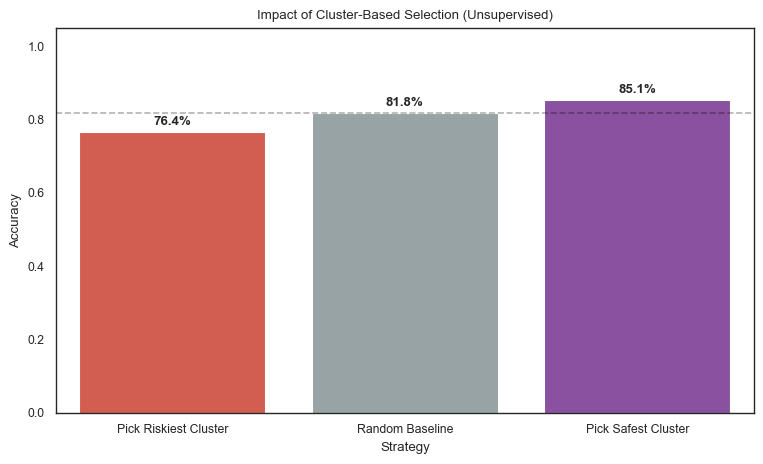

In [11]:
def analyze_intra_question_cluster_subset(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K (same logic as dashboard)
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    # This becomes our "Probability of Correctness" proxy
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    print(f"Identified {n_clusters} clusters. Safety Scores (Accuracy) range: {cluster_accs.min():.1%} - {cluster_accs.max():.1%}")

    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if all answers fall into clusters with identical accuracy
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Picked the safest cluster?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Picked the riskiest cluster?
            'Random_Baseline': group['Correct'].mean(),
            'Safety_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ Clusters did not differentiate answers within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 4. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Cluster-Based Selection Strategy</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer belonging to the cluster with highest historical accuracy.<br>
            (Re-clustered on single-sample metrics only)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#8e44ad'>{acc_best:.1%}</div>
                <div style='color:#8e44ad; font-weight:bold; font-size:0.8em'>Best Cluster</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Cluster</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest Cluster', 'Random Baseline', 'Pick Safest Cluster'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Cluster-Based Selection (Unsupervised)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset(df)

🔍 Analyzing all 31 feature subsets...


,Feature,Impact,Verdict
4,Length,-1.87%,TOSS
2,Heuristic,-0.14%,TOSS
1,LogitGap,-0.03%,TOSS
3,Mechanistic,2.96%,KEEP
0,Entropy,4.99%,KEEP


,Size,Features,Acc_Best,Acc_Worst,Gap
0,2,"Entropy, LogitGap",86.1%,75.5%,10.6%
1,2,"Entropy, Heuristic",86.2%,75.7%,10.5%
2,4,"Entropy, LogitGap, Heuristic, Mechanistic",86.1%,75.7%,10.4%
3,1,Entropy,85.9%,75.5%,10.4%
4,3,"Entropy, LogitGap, Heuristic",86.1%,75.8%,10.3%


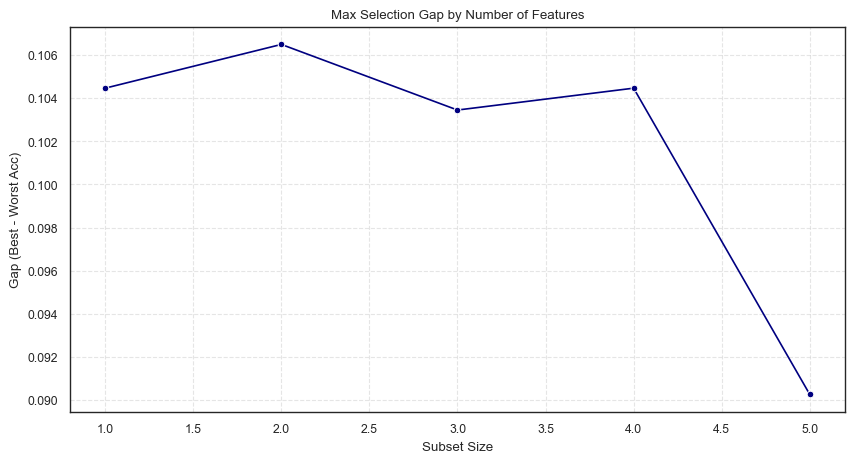

In [12]:
def analyze_feature_redundancy(df):
    import itertools
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from IPython.display import display, HTML
    
    # 1. Setup
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length']
    results = []
    
    print(f"🔍 Analyzing all {2**len(features) - 1} feature subsets...")
    
    # Pre-scale to speed up the loop
    X_raw = df[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=features, index=df.index)
    y = df['Correct']
    
    # Pre-filter for evaluation (Questions with multiple answers)
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    eval_mask = grouped[group_col].transform('count') > 1
    eval_df_base = df.loc[eval_mask, [group_col, 'Correct']].copy()
    
    if len(eval_df_base) == 0:
        print("⚠️ No multi-answer questions found to analyze.")
        return

    # 2. Brute-Force Search
    for r in range(1, len(features) + 1):
        for subset in itertools.combinations(features, r):
            cols = list(subset)
            
            # Train Fusion Model
            clf = LogisticRegression(class_weight='balanced', random_state=42)
            clf.fit(X_scaled[cols], y)
            
            # Predict
            probs = clf.predict_proba(X_scaled[cols])[:, 1]
            prob_series = pd.Series(probs, index=df.index)
            
            # Evaluate Selection Gap
            current_eval = eval_df_base.copy()
            current_eval['probs'] = prob_series[eval_mask]
            
            # Find best/worst per question
            g = current_eval.groupby(group_col)['probs']
            best_idx = g.idxmax()
            worst_idx = g.idxmin()
            
            # Only count questions where model actually distinguishes (Prob Best != Prob Worst)
            distinct_mask = current_eval.loc[best_idx, 'probs'].values != current_eval.loc[worst_idx, 'probs'].values
            
            valid_best = best_idx[distinct_mask]
            valid_worst = worst_idx[distinct_mask]
            
            if len(valid_best) > 0:
                acc_best = current_eval.loc[valid_best, 'Correct'].mean()
                acc_worst = current_eval.loc[valid_worst, 'Correct'].mean()
                gap = acc_best - acc_worst
                
                results.append({
                    'Size': len(cols),
                    'Features': ", ".join(cols),
                    'Acc_Best': acc_best,
                    'Acc_Worst': acc_worst,
                    'Gap': gap
                })

    # 3. Process Results
    res_df = pd.DataFrame(results).sort_values('Gap', ascending=False).reset_index(drop=True)
    
    # 4. Dispensability Analysis (Impact Score)
    # How much does the Gap drop when we REMOVE this feature?
    feature_impact = []
    for f in features:
        # Average Gap of subsets WITH feature f
        with_f = res_df[res_df['Features'].str.contains(f)]['Gap'].mean()
        # Average Gap of subsets WITHOUT feature f
        without_f = res_df[~res_df['Features'].str.contains(f)]['Gap'].mean()
        
        impact = with_f - without_f
        feature_impact.append({
            'Feature': f, 
            'Impact': impact,
            'Verdict': 'KEEP' if impact > 0.02 else ('BORDERLINE' if impact > 0 else 'TOSS')
        })
    
    impact_df = pd.DataFrame(feature_impact).sort_values('Impact', ascending=True)

    # --- DISPLAYS ---
    
    # A. Variable Impact Table
    html_impact = "<h3>🗑️ Variable Dispensability (Sorted by 'Freest to Throw Out')</h3>"
    html_impact += "<p><i>Low or Negative Impact = Removing this variable doesn't hurt (or helps).</i></p>"
    html_impact += impact_df.style.bar(subset=['Impact'], align='mid', color=['#e74c3c', '#27ae60'])\
        .format("{:.2%}", subset=['Impact'])\
        .to_html()
    display(HTML(html_impact))
    
    # B. Top Subsets Table
    html_top = "<h3>🏆 Top 5 Feature Combinations</h3>"
    html_top += res_df.head(5).style.background_gradient(subset=['Gap'], cmap='Greens')\
        .format("{:.1%}", subset=['Acc_Best', 'Acc_Worst', 'Gap'])\
        .to_html()
    display(HTML(html_top))

    # C. Complexity vs Performance Plot
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=res_df, x='Size', y='Gap', marker='o', color='navy', estimator=np.max, errorbar=None)
    plt.title("Max Selection Gap by Number of Features")
    plt.ylabel("Gap (Best - Worst Acc)")
    plt.xlabel("Subset Size")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- EXECUTE ---
analyze_feature_redundancy(df)

Re-clustering using subset: ['Entropy', 'LogitGap', 'Mechanistic']...
Identified 12 clusters. Safety Scores (Accuracy) range: 30.3% - 97.6%
Analyzing 986 questions with multiple answers...


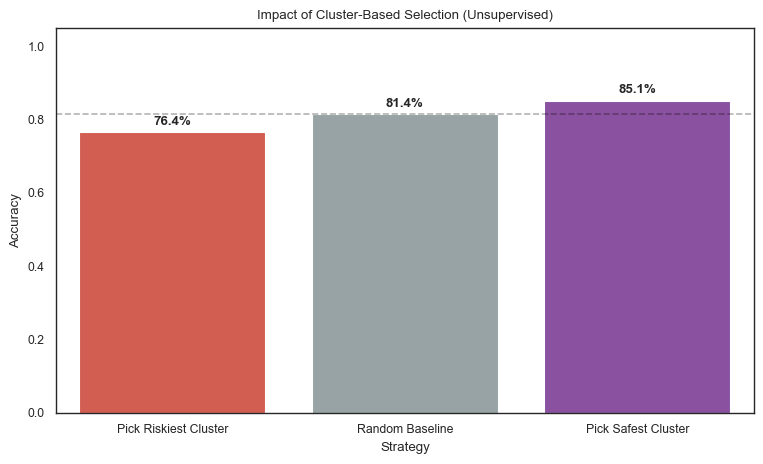

In [13]:
def analyze_intra_question_cluster_subset(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Mechanistic']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K (same logic as dashboard)
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    # This becomes our "Probability of Correctness" proxy
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    print(f"Identified {n_clusters} clusters. Safety Scores (Accuracy) range: {cluster_accs.min():.1%} - {cluster_accs.max():.1%}")

    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    results = []
    
    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Skip if all answers fall into clusters with identical accuracy
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        results.append({
            'Question': q_id,
            'Selected_Best_Correct': group.loc[id_best, 'Correct'],   # Picked the safest cluster?
            'Selected_Worst_Correct': group.loc[id_worst, 'Correct'], # Picked the riskiest cluster?
            'Random_Baseline': group['Correct'].mean(),
            'Safety_Spread': group.loc[id_best, prob_col] - group.loc[id_worst, prob_col]
        })

    if not results:
        print("⚠️ Clusters did not differentiate answers within groups.")
        return

    res_df = pd.DataFrame(results)

    # --- 4. CALCULATE & VISUALIZE ---
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    # HTML Summary
    delta = acc_best - acc_base
    color = "#27ae60" if delta > 0 else "#c0392b"
    
    html = f"""
    <div style='border:1px solid #ddd; padding:15px; border-radius:8px; margin-bottom:20px; background:white'>
        <h3 style='margin-top:0; color:#2c3e50'>Cluster-Based Selection Strategy</h3>
        <div style='font-size:0.9em; color:#666; margin-bottom:10px'>
            Strategy: Pick answer belonging to the cluster with highest historical accuracy.<br>
            (Re-clustered on single-sample metrics only)
        </div>
        
        <div style='display:flex; gap:20px; align-items:flex-end'>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#7f8c8d'>{acc_base:.1%}</div>
                <div style='color:#7f8c8d; font-size:0.8em'>Random Baseline</div>
            </div>
            <div style='font-size:2em; color:#ccc'>→</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#8e44ad'>{acc_best:.1%}</div>
                <div style='color:#8e44ad; font-weight:bold; font-size:0.8em'>Best Cluster</div>
            </div>
            <div style='font-size:2em; color:#ccc'>vs</div>
            <div style='text-align:center'>
                <div style='font-size:2em; font-weight:bold; color:#c0392b'>{acc_worst:.1%}</div>
                <div style='color:#c0392b; font-size:0.8em'>Worst Cluster</div>
            </div>
        </div>
        <div style='margin-top:10px; font-weight:bold; color:{color}; font-size:1.1em'>
            Gain: {delta:+.1%} accuracy
        </div>
    </div>
    """
    display(HTML(html))

    # Plot
    plt.figure(figsize=(9, 5))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest Cluster', 'Random Baseline', 'Pick Safest Cluster'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='black', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
        
    plt.title("Impact of Cluster-Based Selection (Unsupervised)")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset(df)

Re-clustering using subset: ['Entropy', 'LogitGap', 'Mechanistic']...
Analyzing 986 questions with multiple answers...


Question,Safest_Ans,Safest_Cluster_Acc,Riskiest_Ans,Riskiest_Cluster_Acc
"Weng earns $12 an hour for babysitting. Yesterday, she just did 50 minutes of babysitting. How much did she earn?",50,95.2%,14.80,35.1%
"Janice can type 6 sentences per minute. Today at work, Janice continued working on a paper she started typing yesterday. She typed for 20 minutes, took a break, and typed 15 minutes longer. She then had to erase 40 sentences she had typed incorrectly. After a meeting, she typed for 18 minutes more. In all, the paper had 536 sentences by the end of today. How many sentences did she start with today?",258,80.5%,814,35.1%
"There is very little car traffic on Happy Street. During the week, most cars pass it on Tuesday - 25. On Monday, 20% less than on Tuesday, and on Wednesday, 2 more cars than on Monday. On Thursday and Friday, it is about 10 cars each day. On the weekend, traffic drops to 5 cars per day. How many cars travel down Happy Street from Monday through Sunday?",97,89.3%,137,56.7%
Stella and Twinkle are filling up a truck with a capacity of 6000 stone blocks at the rate of 250 blocks per hour per person. They work for four hours and are then joined by 6 other people who also work at the same rate. How many hours did filling the truck take?,6,80.5%,6.67,30.3%
"A school principal is booking hotel rooms for a class of 30 students to stay at during an overnight field trip. Each of the hotel's rooms has two queen size beds, which can fit two students each, and a pull-out couch, which can fit one student. How many rooms does the principal need to book to fit all of the students in the class?",30,76.6%,8,35.1%


Question,Safest_Ans (Wrong),Safest_Cluster_Acc,Riskiest_Ans (Correct),Riskiest_Cluster_Acc
"Jeanette is practicing her juggling. Each week she can juggle 2 more objects than the week before. If she starts out juggling 3 objects and practices for 5 weeks, how many objects can she juggle?",35,95.2%,13,89.3%
"In a conference room, 40 chairs with a capacity of 2 people each were arranged in rows in preparation for the board meeting of a company, whose number of members was the same as the chairs' capacity. If 2/5 of the chairs were not occupied, and the rest each had two people, calculate the number of board members who did attend the meeting.",24,80.5%,48,76.6%
John throws a block party and splits the cost with 3 other people. They buy 100 pounds of burgers at $3 per pound. They also buy $80 of condiments and propane to cook everything. John also buys all the alcohol which costs $200. How much did John spend altogether,145,76.6%,295,35.1%
"Daniel has a collection of 346 video games. 80 of them, Daniel bought for $12 each. Of the rest, 50% were bought for $7. All others had a price of $3 each. How much did Daniel spend on all the games in his collection?",1,86.5%,0,80.5%
"Manex is a tour bus driver. He has to drive 55 miles to the destination and drive going back to the starting point on a different way that is 10 miles farther. If he can drive 1 mile for 2 minutes and stayed 2 hours at the destination, how long will it take the bus driver to do the entire tour in hours?",62,80.5%,6,56.7%


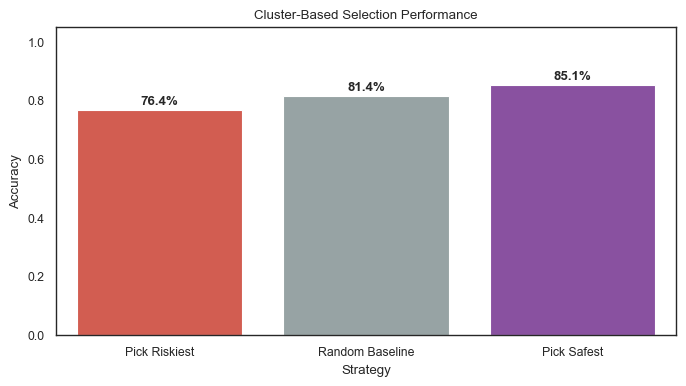

In [14]:
def analyze_intra_question_cluster_subset_with_examples(df):
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from IPython.display import display, HTML

    # --- 1. RE-CLUSTER (Subset Features Only) ---
    subset_features = ['Entropy', 'LogitGap', 'Mechanistic']
    print(f"Re-clustering using subset: {subset_features}...")
    
    # Prepare Data
    X = df[subset_features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Adaptive K
    n_clusters = min(12, len(df)//10) if len(df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # --- 2. CALCULATE CLUSTER "SAFETY" SCORES ---
    df['Temp_Cluster'] = labels
    cluster_accs = df.groupby('Temp_Cluster')['Correct'].mean()
    
    # Map the cluster's accuracy to the individual sample
    prob_col = 'Cluster_Safety_Score'
    df[prob_col] = df['Temp_Cluster'].map(cluster_accs)
    
    # --- 3. INTRA-QUESTION ANALYSIS ---
    group_col = 'question_id_external' if 'question_id_external' in df.columns else 'question_text'
    grouped = df.groupby(group_col)
    multi_sample_mask = grouped[prob_col].transform('count') > 1
    sub_df = df[multi_sample_mask].copy()
    
    if len(sub_df) == 0:
        print("⚠️ Not enough data: No questions have multiple answers.")
        return

    wins = []       # Safest was Correct, Riskiest was Wrong
    losses = []     # Safest was Wrong, Riskiest was Correct
    results = []    # Aggregate stats
    
    print(f"Analyzing {len(sub_df[group_col].unique())} questions with multiple answers...")

    for q_id, group in sub_df.groupby(group_col):
        if len(group) < 2: continue
        
        # Find index of Safest (Best Cluster) and Riskiest (Worst Cluster) answers
        id_best = group[prob_col].idxmax()
        id_worst = group[prob_col].idxmin()
        
        # Get accuracy values
        best_is_correct = group.loc[id_best, 'Correct']
        worst_is_correct = group.loc[id_worst, 'Correct']
        
        # Skip if the metric didn't distinguish (e.g. both answers fell into the same cluster)
        if group.loc[id_best, prob_col] == group.loc[id_worst, prob_col]:
            continue

        # Track Wins/Losses
        q_text = group.iloc[0]['question_text']
        
        # CASE 1: IMPROVEMENT (The mechanism worked)
        # We picked a Correct answer because it was in a "Safe" cluster,
        # avoiding an Incorrect answer that was in a "Risky" cluster.
        if best_is_correct == 1 and worst_is_correct == 0:
            wins.append({
                'Question': q_text,
                'Safest_Ans': group.loc[id_best, 'predicted_answer'],
                'Safest_Cluster_Acc': f"{group.loc[id_best, prob_col]:.1%}",
                'Riskiest_Ans': group.loc[id_worst, 'predicted_answer'],
                'Riskiest_Cluster_Acc': f"{group.loc[id_worst, prob_col]:.1%}",
            })
            
        # CASE 2: REGRESSION (The mechanism failed)
        # We picked an Incorrect answer because it looked "Safe" (low entropy, etc),
        # but the actually Correct answer looked "Risky" (high entropy, etc).
        elif best_is_correct == 0 and worst_is_correct == 1:
            losses.append({
                'Question': q_text,
                'Safest_Ans (Wrong)': group.loc[id_best, 'predicted_answer'],
                'Safest_Cluster_Acc': f"{group.loc[id_best, prob_col]:.1%}",
                'Riskiest_Ans (Correct)': group.loc[id_worst, 'predicted_answer'],
                'Riskiest_Cluster_Acc': f"{group.loc[id_worst, prob_col]:.1%}",
            })

        results.append({
            'Selected_Best_Correct': best_is_correct,
            'Selected_Worst_Correct': worst_is_correct,
            'Random_Baseline': group['Correct'].mean()
        })

    # --- 4. PRINT EXAMPLES ---
    
    def render_examples(title, data, color):
        if not data: return
        ex_df = pd.DataFrame(data)
        # Show top 5
        display(HTML(f"<h4 style='color:{color}'>{title} ({len(data)} instances)</h4>"))
        display(ex_df.head(5).style.hide(axis='index').set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

    # Show Improvements (Green)
    render_examples("✅ IMPROVED EXAMPLES (Selection Saved Us)", wins, "#27ae60")
    
    # Show Regressions (Red)
    render_examples("❌ WORSENED EXAMPLES (Selection Misled Us)", losses, "#c0392b")

    # --- 5. AGGREGATE PLOT ---
    if not results: return
    res_df = pd.DataFrame(results)
    acc_best = res_df['Selected_Best_Correct'].mean()
    acc_worst = res_df['Selected_Worst_Correct'].mean()
    acc_base = res_df['Random_Baseline'].mean()
    
    plt.figure(figsize=(8, 4))
    plot_data = pd.DataFrame({
        'Strategy': ['Pick Riskiest', 'Random Baseline', 'Pick Safest'],
        'Accuracy': [acc_worst, acc_base, acc_best]
    })
    ax = sns.barplot(x='Strategy', y='Accuracy', data=plot_data, palette=['#e74c3c', '#95a5a6', '#8e44ad'])
    plt.ylim(0, 1.05)
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
    plt.title("Cluster-Based Selection Performance")
    plt.ylabel("Accuracy")
    plt.show()

# --- RUN IT ---
analyze_intra_question_cluster_subset_with_examples(df)

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML

def analyze_intra_question_concise(df):
    """
    Concise Analysis:
    1. Maps technical column names to readable features.
    2. Clusters answers to find 'Safe' vs 'Risky' patterns.
    3. Prints top 3 examples where the model is conflicted.
    4. Plots the potential gain from choosing the 'Safe' cluster.
    """
    
    # 1. ROBUST COLUMN MAPPING
    # Maps your raw SQL columns to the features needed for clustering
    col_map = {
        'uq_avg_entropy': 'Entropy',
        'uq_heuristic_score': 'LogitGap', 
        'uq_mech_score': 'Mechanistic',
        'is_correct': 'Correct',
        'question_text': 'Question',
        'predicted_answer': 'Answer_Text'
    }
    # Create a working copy and rename valid columns
    work_df = df.copy()
    work_df.rename(columns={k: v for k, v in col_map.items() if k in work_df.columns}, inplace=True)
    
    # Define features to use (and fill missing ones with 0)
    features = ['Entropy', 'LogitGap', 'Mechanistic']
    for f in features:
        if f not in work_df.columns: work_df[f] = 0.0

    # 2. CLUSTERING & SCORING
    # Group similar answers based on their uncertainty features
    X = work_df[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Dynamic K: Use more clusters for larger datasets
    n_clusters = min(10, len(work_df)//5) if len(work_df) > 50 else 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    work_df['Cluster_ID'] = kmeans.fit_predict(X_scaled)
    
    # Score = The average accuracy of the cluster this answer belongs to
    cluster_accs = work_df.groupby('Cluster_ID')['Correct'].mean()
    work_df['Safety_Score'] = work_df['Cluster_ID'].map(cluster_accs)

    # 3. SELECT REPRESENTATIVE EXAMPLES (HIGH CONTRAST)
    # Filter for questions with multiple answers
    grouped = work_df.groupby('Question')
    multi_ans = [g for _, g in grouped if len(g) > 1]
    
    if not multi_ans:
        print("⚠️ No questions with multiple answers found.")
        return

    # Sort questions by 'Contrast': Difference between best and worst safety score
    # This finds examples where the model is "confused" but the metrics can tell the difference
    multi_ans.sort(key=lambda g: g['Safety_Score'].max() - g['Safety_Score'].min(), reverse=True)
    
    print(f"analyzed {len(multi_ans)} questions. Showing top 3 high-contrast examples...\n")
    print("="*80)

    for i, group in enumerate(multi_ans[:3]):
        # Sort answers by Safety Score
        sorted_group = group.sort_values('Safety_Score', ascending=False)
        q_text = sorted_group.iloc[0]['Question']
        
        print(f"📌 Example {i+1}: {q_text[:100]}...")
        for _, row in sorted_group.iterrows():
            marker = "✅" if row['Correct'] else "❌"
            score = row['Safety_Score']
            ans = str(row.get('Answer_Text', ''))[:80].replace('\n', ' ')
            print(f"   {marker} [Safety: {score:.1%}] {ans}...")
        print("-" * 80)

    # 4. PLOT PERFORMANCE
    # Compare strategies: Picking Safest Cluster vs. Random vs. Riskiest Cluster
    stats = []
    for g in multi_ans:
        stats.append({
            'Best Strategy': g.loc[g['Safety_Score'].idxmax(), 'Correct'],
            'Worst Strategy': g.loc[g['Safety_Score'].idxmin(), 'Correct'],
            'Random Baseline': g['Correct'].mean()
        })
    
    res = pd.DataFrame(stats).mean()
    
    # HTML Summary
    delta = res['Best Strategy'] - res['Random Baseline']
    html = f"""
    <div style='background:#f9f9f9; padding:15px; border-radius:5px; border-left: 5px solid #27ae60;'>
        <h3 style='margin:0'>🚀 Cluster Strategy Gain: +{delta:.1%}</h3>
        <span style='color:#7f8c8d'>Baseline: {res['Random Baseline']:.1%}</span> &rarr; 
        <span style='color:#27ae60; font-weight:bold'>Best Cluster: {res['Best Strategy']:.1%}</span>
    </div>
    """
    display(HTML(html))

    # Bar Plot
    plt.figure(figsize=(7, 4))
    order = ['Worst Strategy', 'Random Baseline', 'Best Strategy']
    colors = ['#c0392b', '#95a5a6', '#27ae60']
    ax = sns.barplot(x=order, y=res[order], palette=colors)
    plt.ylim(0, 1.1)
    plt.title("Impact of Choosing 'Safer' Clusters")
    for i, v in enumerate(res[order]):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
    plt.ylabel("Accuracy")
    plt.show()

# Run
analyze_intra_question_concise(df)

ValueError: Data must be 1-dimensional, got ndarray of shape (10, 2) instead

In [ ]:
# 🔎 Diagnose GPT override vs correctness (DB-backed)

import sqlite3
import pandas as pd

DB_PATH = "db/results.sqlite"  # must match DBManager

QUESTION_SUBSTR = "Natalia sold clips"

conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query(
    """
    SELECT
        question_text,
        predicted_answer,
        is_correct,
        eval_method,
        gpt_eval_reason,
        uq_avg_entropy,
        uq_mech_score,
        uq_heuristic_score
    FROM results
    WHERE question_text LIKE ?
    """,
    conn,
    params=(f"%{QUESTION_SUBSTR}%",)
)

conn.close()

# Display cleanly
pd.set_option("display.max_colwidth", 200)
display(df.sort_values(["is_correct", "uq_mech_score"], ascending=[False, False]))


,question_text,predicted_answer,is_correct,eval_method,gpt_eval_reason,uq_avg_entropy,uq_mech_score,uq_heuristic_score
0,"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?",72,1,Local_MPS_LLM,The student correctly calculated the number of clips sold in May and then added that to the number sold in April to find the total.,0.071917,0.966309,0.407421
2,"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?",72\nThe answer is: 72,1,Local_MPS_LLM,The student correctly calculated the number of clips Natalia sold in each month and then added the two amounts to find the total number of clips sold in April and May.,0.040688,0.962013,0.433654
3,"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?",72,1,Local_MPS_LLM,"The student correctly calculated the number of clips sold in April and May, and then added those two numbers together to find the total.",0.026095,0.952680,0.474816
1,"Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?",72,1,Local_MPS_LLM,The student correctly calculated the number of clips sold in May and added it to the number sold in April to find the total.,0.030487,0.950987,0.482606
